# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Nasywa Aulia Putri
- **Email:** cdcc008d6x1788@student.devacademy.id
- **ID Dicoding:** CDCC008D6X1788
- **Username Dicoding:** nasywa_aulia_putri_ovA5

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah pesanan per bulan selama periode Januari 2017 hingga Desember 2018 dan pada bulan apa terjadi lonjakan atau penurunan signifikan?
- Metode pembayaran apa yang paling sering digunakan dan menghasilkan revenue terbesar selama periode tahun 2018 serta bagaimana perbandingannya dengan tahun 2017?
- Berapa rata-rata waktu pengiriman pesanan dan persentase keterlambatan dibanding estimasi pada periode Januari 2018 hingga Juni 2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & time processing
import datetime as dt

# Warning handler
import warnings
warnings.filterwarnings('ignore')

# Visualisasi interaktif / dashboard
import plotly.express as px

# Geospatial analysis (nilai plus)
import folium
from folium.plugins import MarkerCluster

## Data Wrangling

### Gathering Data

Pada tahap ini dilakukan proses pengumpulan data dengan cara memuat seluruh dataset yang relevan menggunakan `pandas`. Dataset yang digunakan terdiri dari beberapa tabel seperti customers, orders, payments, dan lainnya yang saling berhubungan.

In [2]:
# Load dataset
customers = pd.read_csv("customers_dataset.csv")
orders = pd.read_csv("orders_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
order_payments = pd.read_csv("order_payments_dataset.csv")
order_reviews = pd.read_csv("order_reviews_dataset.csv")
products = pd.read_csv("products_dataset.csv")
sellers = pd.read_csv("sellers_dataset.csv")

# Cek beberapa data
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset terdiri dari beberapa tabel terpisah yang merepresentasikan proses bisnis e-commerce (customer, order, pembayaran, dll).
- Tabel `orders` menjadi tabel utama karena berisi informasi inti transaksi.
- Setiap transaksi memiliki order_id unik yang dapat digunakan untuk menggabungkan dataset lain.
- Data mencakup informasi waktu lengkap (purchase, approved, delivered).
- Status pesanan (`order_status`) menunjukkan kondisi transaksi.

### Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data dengan melihat struktur dataset, tipe data, missing values, duplikasi, dan statistik deskriptif untuk memahami kondisi awal data sebelum dilakukan pembersihan.

In [3]:
# cek info dataset
orders.info()

# cek missing values
orders.isna().sum()

# cek duplikasi
orders.duplicated().sum()

# statistik deskriptif
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Dataset `orders` memiliki 99.441 baris dan 8 kolom.
- Semua kolom masih bertipe object, termasuk kolom tanggal yang seharusnya bertipe datetime.
- Terdapat missing values pada beberapa kolom penting:
  - `order_approved_at`
  - `order_delivered_carrier_date`
  - `order_delivered_customer_date`
- Tidak ditemukan data duplikat pada dataset.
- Mayoritas status pesanan adalah delivered (mendominasi data).
- Kolom `order_id` bersifat unik → tidak ada duplikasi transaksi.
- Data memiliki informasi waktu yang cukup lengkap untuk analisis (purchase hingga delivery).

### Cleaning Data

#### 1. Mengubah tipe data datetime

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Kolom tanggal masih `object`, wajib diubah:

In [5]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**
- Kolom waktu berhasil diubah ke tipe datetime sehingga siap untuk analisis berbasis waktu.
- Memungkinkan analisis seperti tren penjualan per bulan/tahun.
- Dapat menghitung metrik penting seperti durasi pengiriman dan waktu proses order.
- Mempermudah manipulasi data waktu (filter tanggal, ekstrak bulan, hari, dll).
- Meningkatkan akurasi analisis dibanding saat masih bertipe object.

#### 2. Menangani missing values

In [7]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Missing values ditangani dengan pendekatan kontekstual sesuai makna data.

- Kolom `order_approved_at` yang memiliki sedikit missing value diisi menggunakan `order_purchase_timestamp` karena waktu approval umumnya tidak jauh dari waktu pembelian.
- Kolom `order_delivered_carrier_date` dan `order_delivered_customer_date` tidak diubah karena missing value pada kolom ini merepresentasikan kondisi nyata, yaitu pesanan yang belum dikirim atau belum sampai (misalnya status cancelled atau pending).

In [8]:
orders['order_approved_at'].fillna(orders['order_purchase_timestamp'], inplace=True)

In [ ]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**

- Missing value pada `order_approved_at `berhasil diatasi tanpa menghilangkan data.
- Missing pada kolom delivery dipertahankan karena mengandung informasi penting terkait status pesanan.
- Pendekatan ini menjaga keakuratan data dan menghindari bias dalam analisis, terutama untuk analisis pengiriman dan performa order.

#### 3. Menghapus duplikasi

In [9]:
orders.duplicated().sum()

np.int64(0)

Dilakukan pengecekan duplikasi menggunakan `orders.duplicated().sum()` dan tidak ditemukan data yang terduplikasi.

**Insight:**

- Tidak terdapat data duplikat dalam dataset (0 duplikasi).
- Setiap `order_id` bersifat unik sehingga tidak ada transaksi yang tercatat lebih dari satu kali.
- Dataset sudah konsisten dan tidak memerlukan proses penghapusan duplikasi.

#### 4. Merge dataset untuk analisis

In [10]:
df = orders.merge(order_payments, on='order_id')

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,credit_card,3,179.12


Dataset `orders` digabungkan dengan `order_payments` menggunakan kolom `order_id` untuk menggabungkan informasi transaksi dengan metode pembayaran dan nilai pembayaran (revenue).

Alasan Merge:
- Data pembayaran (jenis & nilai) tidak tersedia di tabel `orders`.
- Diperlukan untuk menjawab pertanyaan bisnis terkait metode pembayaran dan revenue.
- `order_id` digunakan sebagai kunci karena bersifat unik pada setiap transak

**Insight:**
- Hasil merge menghasilkan beberapa baris untuk satu `order_id` karena satu order bisa memiliki lebih dari satu metode pembayaran.
- Dataset gabungan memungkinkan analisis total revenue per metode pembayaran.
- Merge ini penting untuk mendapatkan insight bisnis yang lebih lengkap, terutama terkait perilaku pembayaran customer.

In [32]:
# Download Data
df.to_csv('cleaned_merged_data.csv', index=False)
print("Data berhasil disimpan sebagai 'cleaned_merged_data.csv'")

Data berhasil disimpan sebagai 'cleaned_merged_data.csv'


## Exploratory Data Analysis (EDA)

### Explore Struktur Data

In [11]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103886 non-null  object        
 1   customer_id                    103886 non-null  object        
 2   order_status                   103886 non-null  object        
 3   order_purchase_timestamp       103886 non-null  datetime64[ns]
 4   order_approved_at              103886 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101998 non-null  datetime64[ns]
 6   order_delivered_customer_date  100754 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103886 non-null  datetime64[ns]
 8   payment_sequential             103886 non-null  int64         
 9   payment_type                   103886 non-null  object        
 10  payment_installments           103886 non-null  int64         
 11  

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_installments,payment_value
count,103886,103886,101998,100754,103886,103886.000000,103886.000000,103886.000000
mean,2017-12-29 21:48:47.671803648,2017-12-30 08:07:19.078297088,2018-01-03 11:06:26.387154432,2018-01-13 03:07:32.174345216,2018-01-22 16:57:01.257917440,1.092679,2.853349,154.100380
min,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,0.000000,0.000000
25%,2017-09-10 09:01:08.750000128,2017-09-10 18:33:33.750000128,2017-09-14 15:43:18.500000,2017-09-22 17:05:03.500000,2017-09-29 00:00:00,1.000000,1.000000,56.790000
50%,2018-01-17 14:07:54,2018-01-17 18:24:37.500000,2018-01-23 17:48:21.500000,2018-02-01 17:02:26.500000,2018-02-14 00:00:00,1.000000,1.000000,100.000000
75%,2018-05-03 18:35:58.249999872,2018-05-04 03:31:40.500000,2018-05-07 16:11:30,2018-05-15 17:31:00.500000,2018-05-25 00:00:00,1.000000,4.000000,171.837500
max,2018-10-17 17:30:18,2018-10-17 17:30:18,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,29.000000,24.000000,13664.080000
std,NaN,NaN,NaN,NaN,NaN,0.706584,2.687051,217.494064


**Insight:**
- Dataset hasil merge memiliki 103.886 baris dan 12 kolom, menunjukkan adanya duplikasi order akibat multiple payment dalam satu transaksi.
- Kolom sudah memiliki tipe data yang sesuai (datetime, numeric, object) → siap untuk analisis lanjutan.
- Masih terdapat missing values pada kolom pengiriman (`order_delivered_*`) yang merepresentasikan order belum selesai.
- Rata-rata nilai transaksi (payment_value) sekitar 154 dengan variasi yang cukup besar (indikasi adanya outlier).
- Mayoritas transaksi memiliki 1 metode pembayaran (`payment_sequential ≈ 1`).
- Pembayaran umumnya dilakukan dengan 1–4 cicilan, tetapi ada yang hingga 24 cicilan.

### Explore Tren Jumlah Order (per bulan)

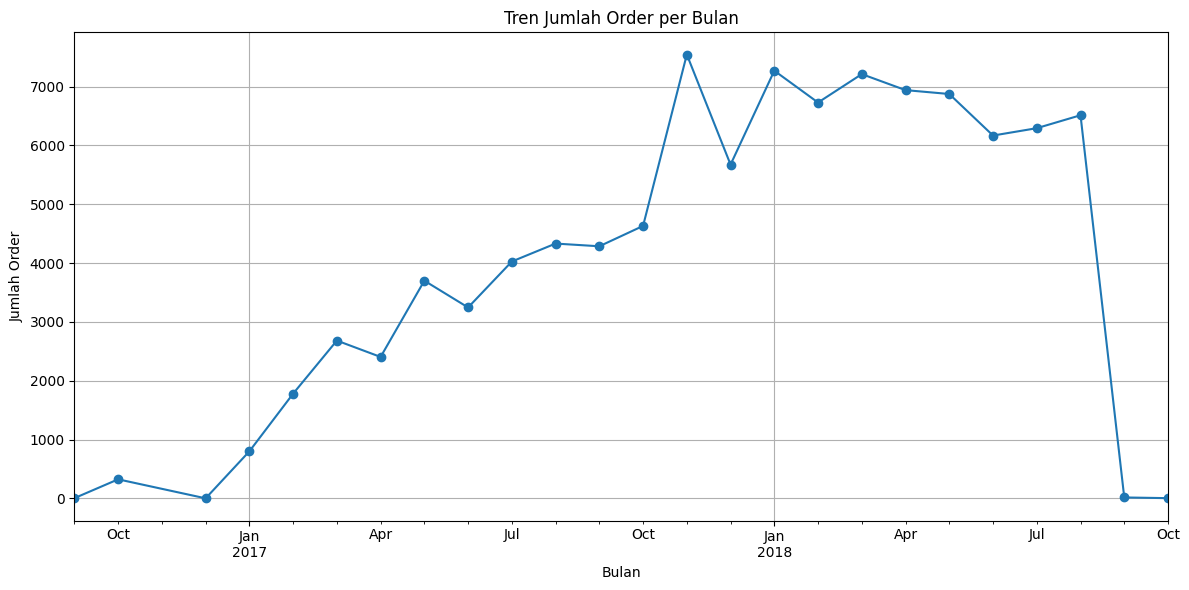

In [12]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('month')['order_id'].count()

plt.figure(figsize=(12, 6))
monthly_orders.plot(kind='line', marker='o')
plt.title('Tren Jumlah Order per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.grid(True)
plt.tight_layout()
plt.show()


**Insight:**
- Terjadi tren peningkatan signifikan jumlah order dari awal periode hingga akhir 2017.
- Puncak order terjadi sekitar akhir 2017 – awal 2018, menunjukkan performa bisnis tertinggi.
- Setelah puncak, jumlah order cenderung stabil dengan sedikit fluktuasi di tahun 2018.
- Terlihat penurunan tajam di akhir periode, kemungkinan karena data belum lengkap (bukan penurunan nyata).
- Secara keseluruhan, bisnis menunjukkan pertumbuhan positif dengan pola musiman ringan.

### Explore Distribusi Status Order

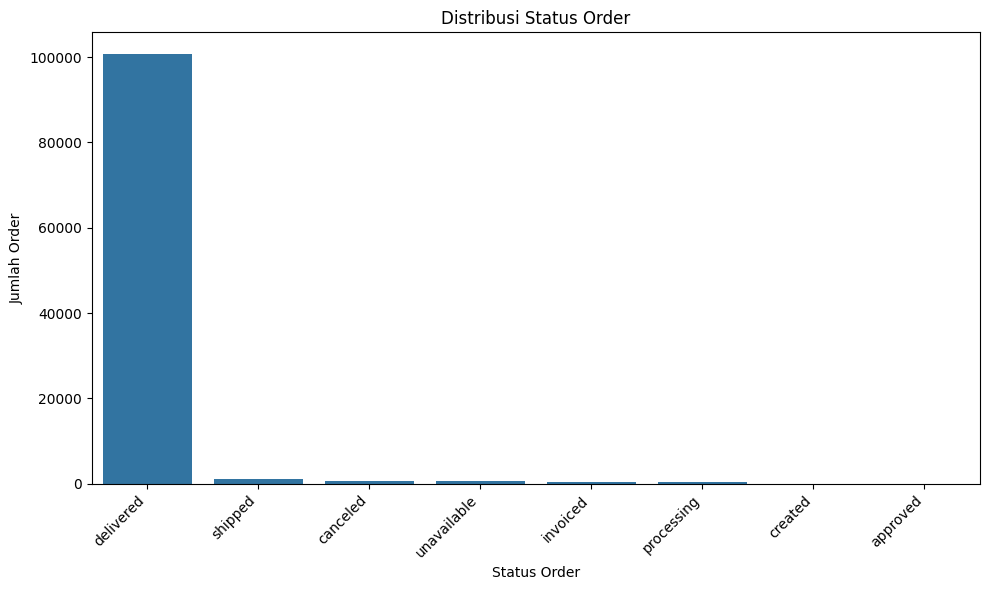

In [13]:
status_counts = df['order_status'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title('Distribusi Status Order')
plt.xlabel('Status Order')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**
- Mayoritas pesanan berstatus 'delivered', menunjukkan tingkat keberhasilan pengiriman yang tinggi.
- Status 'shipped' menjadi yang terbanyak kedua, diikuti oleh 'canceled' dan 'unavailable'.
- Perlu analisis lebih lanjut untuk memahami alasan di balik pesanan yang dibatalkan atau tidak tersedia serta untuk mengoptimalkan proses pengiriman.

### Explore Outlier Revenue

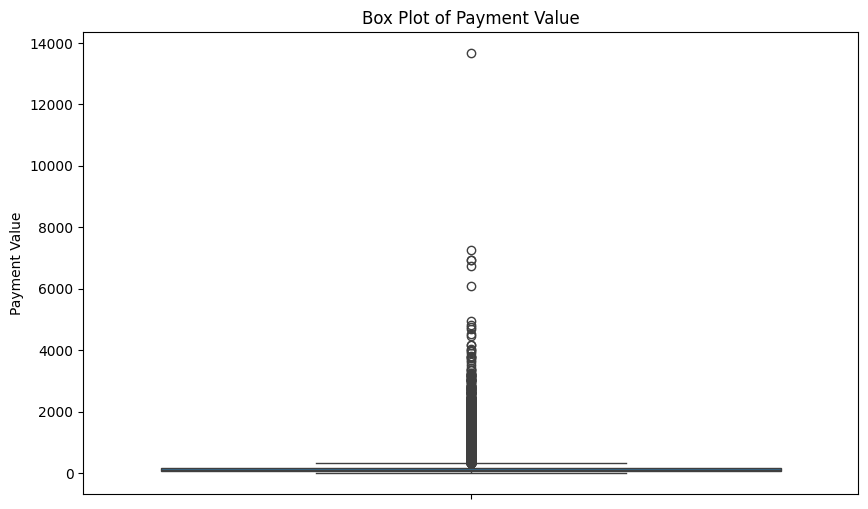

In [14]:
df['payment_value'].describe()

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['payment_value'])
plt.title('Box Plot of Payment Value')
plt.ylabel('Payment Value')
plt.show()

**Insight:**
- Box plot menunjukkan adanya banyak outlier pada 'payment_value', terutama di sisi nilai yang lebih tinggi. Hal ini mengindikasikan bahwa ada beberapa transaksi dengan nilai pembayaran yang sangat besar, jauh di atas sebagian besar transaksi lainnya.
- Outlier ini perlu ditinjau lebih lanjut untuk memahami apakah itu transaksi valid yang signifikan atau anomali data (misalnya, kesalahan input).
- Meskipun ada outlier, mayoritas data 'payment_value' terkonsentrasi pada rentang nilai yang lebih rendah, sesuai dengan kuartil yang terlihat dari `describe()`.

## Explore Metode Pembayaran Paling Sering Digunakan

In [15]:
df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


**Insight:**
- Credit card merupakan metode pembayaran yang paling dominan (±74%) yang menunjukkan preferensi utama pelanggan.
- Metode boleto berada di posisi kedua, tetapi dengan selisih yang cukup jauh dari credit card.
- Voucher dan debit card digunakan dalam jumlah yang relatif kecil.
- Metode not_defined sangat sedikit sehingga tidak signifikan dalam analisis.
- Secara keseluruhan, pelanggan cenderung memilih metode pembayaran yang praktis dan fleksibel (credit card).

## Explore Total Revenue per Metode Pembayaran

In [16]:
payment_revenue = df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

payment_revenue

,payment_value
payment_type,
credit_card,12542084.19
boleto,2869361.27
voucher,379436.87
debit_card,217989.79
not_defined,0.00


**Insight:**
- Credit card menghasilkan revenue terbesar secara signifikan (±12.5 juta), jauh melampaui metode lainnya.
- Boleto menjadi kontributor kedua, tetapi dengan selisih yang cukup besar dari credit card.
- Voucher dan debit card memberikan kontribusi revenue yang relatif kecil.
- Metode not_defined tidak memberikan kontribusi revenue yang berarti.
- Hal ini menunjukkan bahwa credit card tidak hanya paling sering digunakan, tetapi juga paling berkontribusi terhadap pendapatan bisnis.

## Explore Rata-rata Nilai Pembayaran

In [17]:
df['payment_value'].mean()

np.float64(154.10038041699553)

**Insight:**
- Rata-rata nilai transaksi adalah sekitar 154 yang menunjukkan nilai pembelian per order cenderung berada pada level menengah.
- Nilai ini dapat dijadikan acuan untuk memahami daya beli rata-rata pelanggan.
- Perbedaan antara rata-rata dan nilai maksimum yang sangat tinggi mengindikasikan adanya outlier transaksi besar.
- Insight ini bisa digunakan untuk strategi seperti upselling atau promosi untuk meningkatkan nilai transaksi.

## Explore untuk Pertanyaan 1

In [18]:
#Data Preparation
# convert ke datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# filter periode
orders_2017_2018 = orders[
    (orders['order_purchase_timestamp'] >= '2017-01-01') &
    (orders['order_purchase_timestamp'] <= '2018-12-31')
]

# buat kolom bulan
orders_2017_2018['order_month'] = orders_2017_2018['order_purchase_timestamp'].dt.to_period('M')

In [19]:
# Agregasi Data
monthly_orders = orders_2017_2018.groupby('order_month')['order_id'].count().reset_index()
monthly_orders.rename(columns={'order_id': 'total_orders'}, inplace=True)

monthly_orders.head()

,order_month,total_orders
0,2017-01,800
1,2017-02,1780
2,2017-03,2682
3,2017-04,2404
4,2017-05,3700


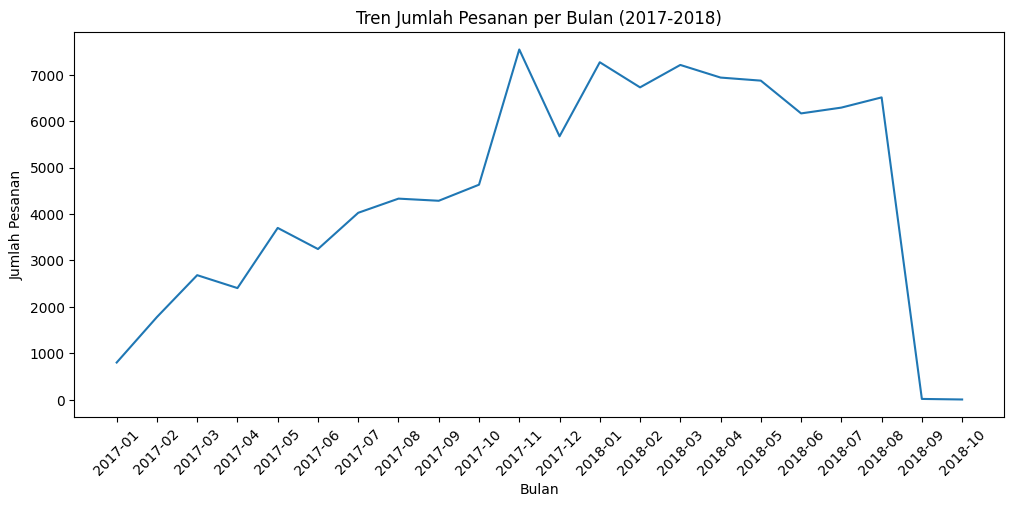

In [20]:
# Visualisasi
plt.figure(figsize=(12,5))
plt.plot(monthly_orders['order_month'].astype(str), monthly_orders['total_orders'])

plt.title('Tren Jumlah Pesanan per Bulan (2017-2018)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)

plt.show()

Proses eksplorasi data dilakukan dengan mengolah kolom waktu pemesanan (`order_purchase_timestamp`) menjadi format datetime agar dapat dianalisis berdasarkan periode waktu. Selanjutnya, data difilter untuk hanya mencakup transaksi pada periode Januari 2017 hingga Desember 2018 sesuai dengan batasan pertanyaan bisnis. Data kemudian dikelompokkan berdasarkan bulan menggunakan representasi period (bulanan) untuk melihat pola agregasi secara lebih jelas. Jumlah pesanan pada setiap bulan dihitung menggunakan teknik grouping dan agregasi. Hasil agregasi tersebut kemudian divisualisasikan dalam bentuk line chart untuk mengidentifikasi tren, pola pertumbuhan serta fluktuasi jumlah pesanan dari waktu ke waktu.

**Insight:**
- Jumlah pesanan menunjukkan tren meningkat sepanjang tahun 2017 hingga mencapai puncaknya pada akhir tahun.
- Pada tahun 2018, jumlah pesanan cenderung stabil dengan fluktuasi kecil di beberapa bulan.
- Terdapat lonjakan pesanan pada periode akhir tahun yang mengindikasikan adanya pola musiman (seasonality).
- Lonjakan pada periode tertentu mengindikasikan adanya kemungkinan efek musiman (seasonality), seperti promo akhir tahun atau event belanja besar.
- Penurunan drastis pada akhir 2018 kemungkinan disebabkan oleh data yang tidak lengkap sehingga tidak mencerminkan kondisi sebenarnya.
- Periode dengan jumlah pesanan tinggi dapat dimanfaatkan sebagai momentum untuk strategi promosi dan peningkatan stok.

### Explore untuk Pertanyaan 2

In [21]:
# Data Preparation
# merge orders + payments
df_payments = pd.merge(orders, order_payments, on='order_id')

# convert datetime
df_payments['order_purchase_timestamp'] = pd.to_datetime(df_payments['order_purchase_timestamp'])

# ambil tahun
df_payments['year'] = df_payments['order_purchase_timestamp'].dt.year

# filter 2017 & 2018
df_payments_filtered = df_payments[df_payments['year'].isin([2017, 2018])]

In [22]:
# Agregasi Data
payment_summary = df_payments_filtered.groupby(['year', 'payment_type']).agg({
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

payment_summary.rename(columns={
    'order_id': 'total_transactions',
    'payment_value': 'total_revenue'
}, inplace=True)

payment_summary.head()

,year,payment_type,total_transactions,total_revenue
0,2017,boleto,9508,1396063.37
1,2017,credit_card,34568,5637373.94
2,2017,debit_card,422,43326.47
3,2017,voucher,3027,172982.95
4,2018,boleto,10213,1463618.84


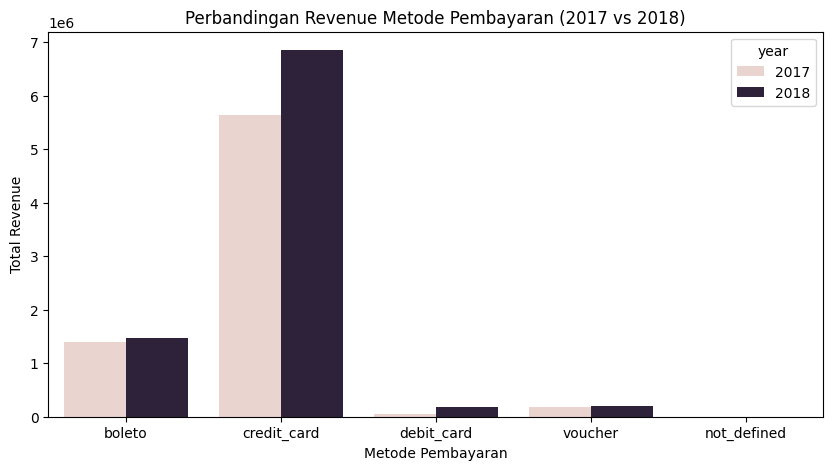

In [23]:
# Visualisasi
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=payment_summary, x='payment_type', y='total_revenue', hue='year')

plt.title('Perbandingan Revenue Metode Pembayaran (2017 vs 2018)')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Total Revenue')

plt.show()

Proses eksplorasi data untuk menganalisis metode pembayaran dimulai dengan menggabungkan dataset orders dan `order_payments` untuk memperoleh informasi transaksi beserta metode pembayaran yang digunakan. Selanjutnya, kolom waktu pemesanan dikonversi ke format datetime untuk mengekstrak informasi tahun transaksi. Data kemudian difilter untuk hanya mencakup transaksi pada tahun 2017 dan 2018 sesuai dengan fokus analisis. Setelah itu, dilakukan pengelompokan data berdasarkan tahun dan jenis metode pembayaran untuk menghitung jumlah transaksi serta total revenue yang dihasilkan oleh masing-masing metode. Hasil agregasi tersebut divisualisasikan menggunakan bar chart untuk membandingkan kontribusi setiap metode pembayaran antara tahun 2017 dan 2018.

**Insight:**
- Metode pembayaran credit card mendominasi baik dari sisi jumlah transaksi maupun total revenue pada tahun 2017 dan 2018.
- Terjadi peningkatan revenue pada hampir semua metode pembayaran di tahun 2018 dibandingkan 2017 yang menunjukkan pertumbuhan transaksi.
- Metode boleto menjadi alternatif kedua yang cukup signifikan dalam kontribusi revenue, meskipun masih jauh di bawah credit card.
- Metode pembayaran seperti debit card dan voucher memiliki kontribusi yang relatif kecil terhadap total revenue.
- Dominasi credit card menunjukkan preferensi pelanggan terhadap metode pembayaran yang praktis dan fleksibel sehingga dapat menjadi fokus dalam strategi bisnis seperti promo atau peningkatan fitur pembayaran.
- Peningkatan signifikan pada credit card mengindikasikan potensi optimalisasi melalui program cicilan atau cashback untuk meningkatkan konversi transaksi.

### Explore untuk Pertanyaan 3

In [24]:
# Data Preparation
# convert datetime
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# filter periode
orders_2018 = orders[
    (orders['order_purchase_timestamp'] >= '2018-01-01') &
    (orders['order_purchase_timestamp'] <= '2018-06-30')
]

In [25]:
# delivery time (hari)
orders_2018['delivery_time'] = (
    orders_2018['order_delivered_customer_date'] -
    orders_2018['order_purchase_timestamp']
).dt.days

# delay (hari)
orders_2018['delay'] = (
    orders_2018['order_delivered_customer_date'] -
    orders_2018['order_estimated_delivery_date']
).dt.days

# tandai terlambat
orders_2018['is_late'] = orders_2018['delay'] > 0

In [26]:
avg_delivery_time = orders_2018['delivery_time'].mean()
late_percentage = orders_2018['is_late'].mean() * 100

avg_delivery_time, late_percentage

(np.float64(12.88455215701903), np.float64(8.469912086306406))

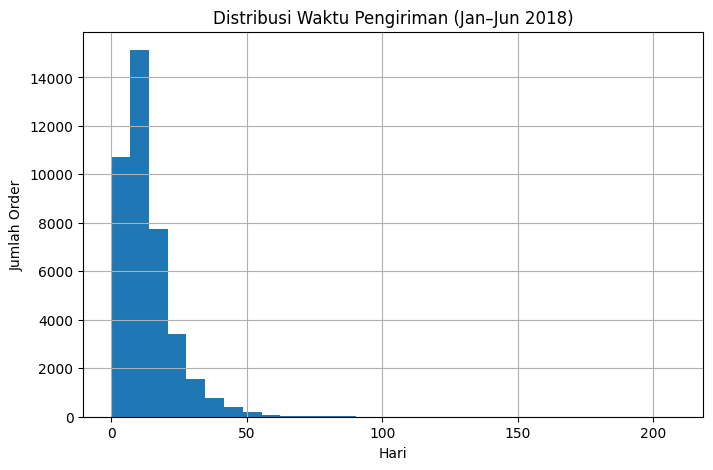

In [27]:
# Visualisasi
plt.figure(figsize=(8,5))
orders_2018['delivery_time'].hist(bins=30)

plt.title('Distribusi Waktu Pengiriman (Jan–Jun 2018)')
plt.xlabel('Hari')
plt.ylabel('Jumlah Order')

plt.show()

Proses eksplorasi data untuk menganalisis performa pengiriman dimulai dengan mengonversi kolom tanggal terkait pengiriman, yaitu `order_purchase_timestamp`, `order_delivered_customer_date`, dan `order_estimated_delivery_date`, ke dalam format datetime. Selanjutnya, data difilter untuk hanya mencakup transaksi pada periode Januari hingga Juni 2018 sesuai dengan batasan analisis. Setelah itu, dihitung durasi pengiriman (delivery time) sebagai selisih antara tanggal pembelian dan tanggal pesanan diterima pelanggan. Selain itu, dihitung juga keterlambatan (delay) sebagai selisih antara tanggal pesanan diterima dengan estimasi pengiriman. Data kemudian diklasifikasikan menjadi pengiriman tepat waktu dan terlambat. Ringkasan statistik seperti rata-rata waktu pengiriman dan persentase keterlambatan dihitung untuk memberikan gambaran performa logistik. Distribusi waktu pengiriman divisualisasikan menggunakan histogram untuk melihat pola sebaran durasi pengiriman.

**Insight:**
- Waktu pengiriman pesanan berada pada kisaran 0 hingga 50 hari yang menunjukkan adanya variasi durasi pengiriman yang cukup besar.
- Sebagian besar pesanan terkonsentrasi pada sekitar 10 hari yang mengindikasikan bahwa mayoritas pengiriman berlangsung dalam waktu yang relatif cepat dan konsisten.
- Terdapat sejumlah kecil pesanan dengan waktu pengiriman yang jauh lebih lama (mendekati 50 hari) yang dapat dikategorikan sebagai outlier.
- Adanya outlier ini menunjukkan potensi kendala dalam proses logistik seperti keterlambatan pengiriman atau masalah operasional.
- Secara keseluruhan, performa pengiriman sudah cukup baik karena mayoritas pesanan terkirim dalam waktu sekitar 10 hari, tetapi perlu evaluasi lebih lanjut untuk mengurangi kasus keterlambatan ekstrem.
- Perusahaan dapat menetapkan standar waktu pengiriman sekitar 10 hari sebagai baseline layanan serta fokus mengurangi kasus pengiriman di atas 20 hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan per bulan selama Januari 2017 – Desember 2018 dan kapan terjadi lonjakan atau penurunan signifikan?

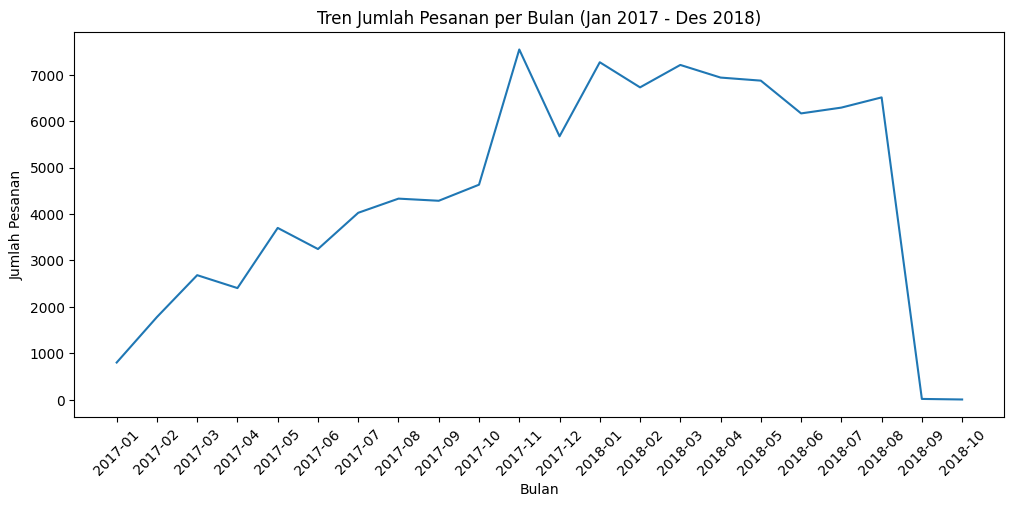

In [28]:
plt.figure(figsize=(12,5))
plt.plot(monthly_orders['order_month'].astype(str), monthly_orders['total_orders'])

plt.title('Tren Jumlah Pesanan per Bulan (Jan 2017 - Des 2018)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)

plt.show()

**Insight:**
- Jumlah pesanan menunjukkan tren meningkat sepanjang tahun 2017 hingga mencapai puncaknya pada akhir tahun.
- Pada tahun 2018, jumlah pesanan cenderung stabil dengan fluktuasi kecil di beberapa bulan.
- Terdapat lonjakan pesanan pada periode akhir tahun yang mengindikasikan adanya pola musiman (seasonality).
- Lonjakan pada periode tertentu mengindikasikan adanya kemungkinan efek musiman (seasonality), seperti promo akhir tahun atau event belanja besar.
- Penurunan drastis pada akhir 2018 kemungkinan disebabkan oleh data yang tidak lengkap sehingga tidak mencerminkan kondisi sebenarnya.
- Periode dengan jumlah pesanan tinggi dapat dimanfaatkan sebagai momentum untuk strategi promosi dan peningkatan stok.

### Pertanyaan 2: Metode pembayaran apa yang paling sering digunakan dan menghasilkan revenue terbesar pada 2018 serta perbandingannya dengan 2017?

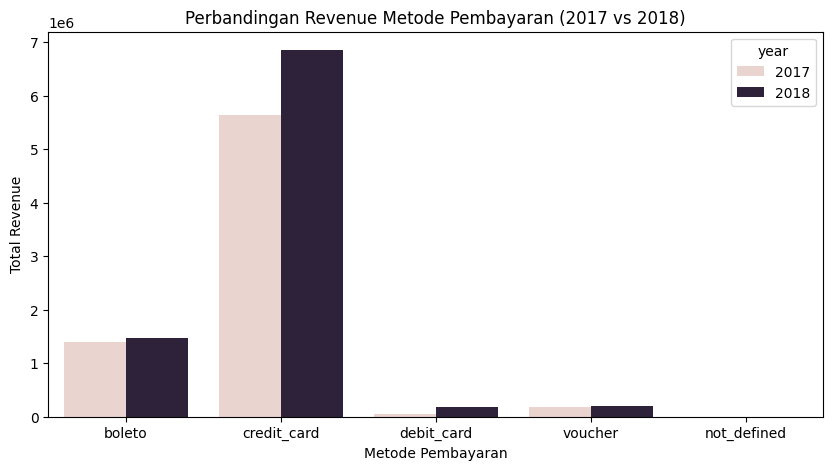

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(data=payment_summary, x='payment_type', y='total_revenue', hue='year')

plt.title('Perbandingan Revenue Metode Pembayaran (2017 vs 2018)')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Total Revenue')

plt.show()

**Insight:**
- Metode pembayaran credit card mendominasi baik dari sisi jumlah transaksi maupun total revenue pada tahun 2017 dan 2018.
- Terjadi peningkatan revenue pada hampir semua metode pembayaran di tahun 2018 dibandingkan 2017 yang menunjukkan pertumbuhan transaksi.
- Metode boleto menjadi alternatif kedua yang cukup signifikan dalam kontribusi revenue, meskipun masih jauh di bawah credit card.
- Metode pembayaran seperti debit card dan voucher memiliki kontribusi yang relatif kecil terhadap total revenue.
- Dominasi credit card menunjukkan preferensi pelanggan terhadap metode pembayaran yang praktis dan fleksibel sehingga dapat menjadi fokus dalam strategi bisnis seperti promo atau peningkatan fitur pembayaran.
- Peningkatan signifikan pada credit card mengindikasikan potensi optimalisasi melalui program cicilan atau cashback untuk meningkatkan konversi transaksi.

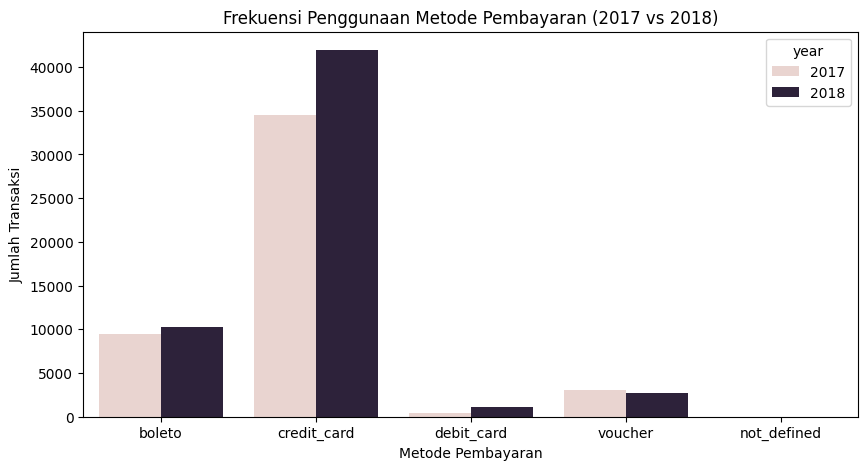

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(data=payment_summary, x='payment_type', y='total_transactions', hue='year')

plt.title('Frekuensi Penggunaan Metode Pembayaran (2017 vs 2018)')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')

plt.show()

### Pertanyaan 3: Berapa rata-rata waktu pengiriman dan persentase keterlambatan pada Januari – Juni 2018?

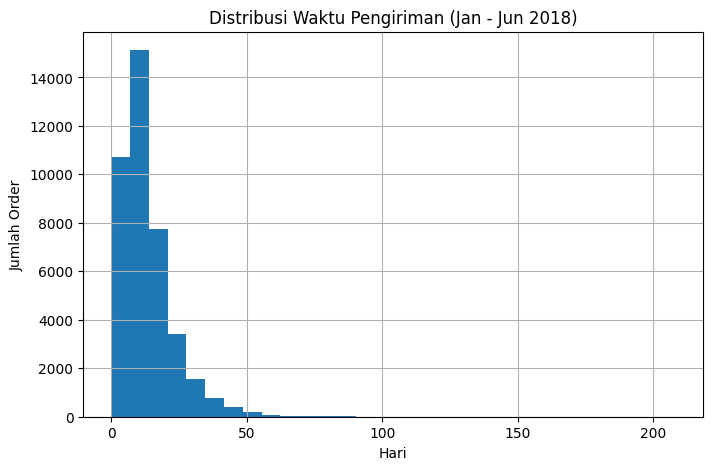

In [31]:
plt.figure(figsize=(8,5))
orders_2018['delivery_time'].hist(bins=30)

plt.title('Distribusi Waktu Pengiriman (Jan - Jun 2018)')
plt.xlabel('Hari')
plt.ylabel('Jumlah Order')

plt.show()

**Insight:**
- Waktu pengiriman pesanan berada pada kisaran 0 hingga 50 hari yang menunjukkan adanya variasi durasi pengiriman yang cukup besar.
- Sebagian besar pesanan terkonsentrasi pada sekitar 10 hari yang mengindikasikan bahwa mayoritas pengiriman berlangsung dalam waktu yang relatif cepat dan konsisten.
- Terdapat sejumlah kecil pesanan dengan waktu pengiriman yang jauh lebih lama (mendekati 50 hari) yang dapat dikategorikan sebagai outlier.
- Adanya outlier ini menunjukkan potensi kendala dalam proses logistik seperti keterlambatan pengiriman atau masalah operasional.
- Secara keseluruhan, performa pengiriman sudah cukup baik karena mayoritas pesanan terkirim dalam waktu sekitar 10 hari, tetapi perlu evaluasi lebih lanjut untuk mengurangi kasus keterlambatan ekstrem.
- Perusahaan dapat menetapkan standar waktu pengiriman sekitar 10 hari sebagai baseline layanan serta fokus mengurangi kasus pengiriman di atas 20 hari.

## Analisis Lanjutan: Evaluasi Kinerja Pengiriman & Segmentasi Delay

In [ ]:
# Filter Data
df_delivered = df[df['order_status'] == 'delivered'].copy()

In [ ]:
# Feature Engineering
# waktu pengiriman
df_delivered['delivery_time'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_purchase_timestamp']
).dt.days

# delay (keterlambatan)
df_delivered['delay'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_estimated_delivery_date']
).dt.days

In [ ]:
# Segmentasi Delay (Clustering Manual / Binning)
def delay_category(x):
    if x <= 0:
        return 'On Time / Early'
    elif x <= 3:
        return 'Slight Delay'
    else:
        return 'Late'

df_delivered['delay_category'] = df_delivered['delay'].apply(delay_category)

In [ ]:
# Analisis Distribusi Segmentasi
delay_dist = df_delivered['delay_category'].value_counts(normalize=True) * 100
delay_dist

,proportion
delay_category,
On Time / Early,93.256977
Late,4.836437
Slight Delay,1.906586


In [ ]:
# Rata-rata Delivery & Delay
avg_delivery = df_delivered['delivery_time'].mean()
avg_delay = df_delivered['delay'].mean()

avg_delivery, avg_delay

(np.float64(12.105887958073609), np.float64(-11.893149243657442))

In [ ]:
# Tren Delay per Bulan
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly_delay = df_delivered.groupby('month')['delay'].mean()
monthly_delay

,delay
month,
2016-10,-35.705674
2016-12,-22.000000
2017-01,-27.513141
2017-02,-19.146369
2017-03,-12.285185
2017-04,-12.997537
2017-05,-13.424194
2017-06,-12.437255
2017-07,-12.505426


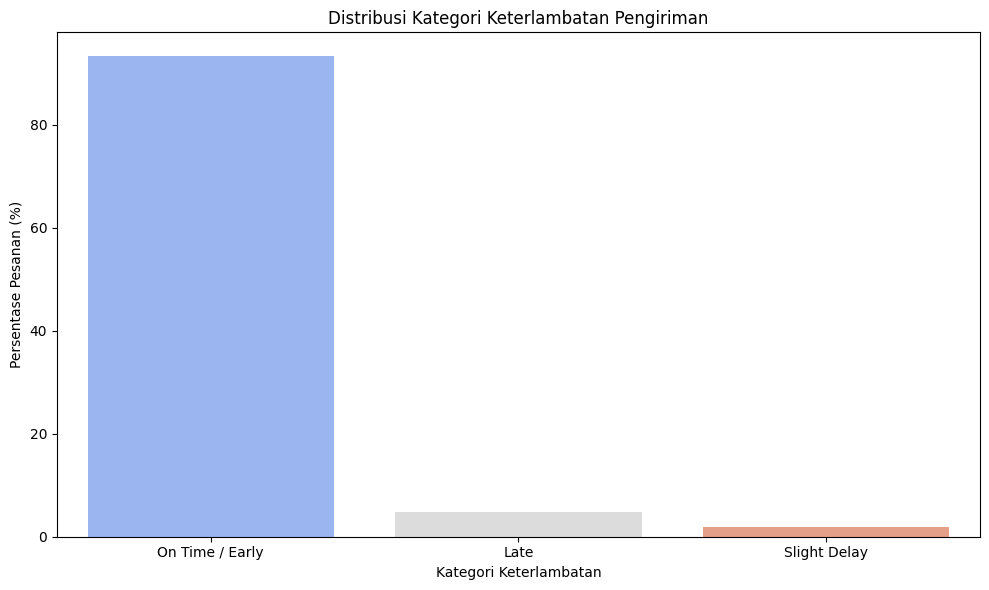

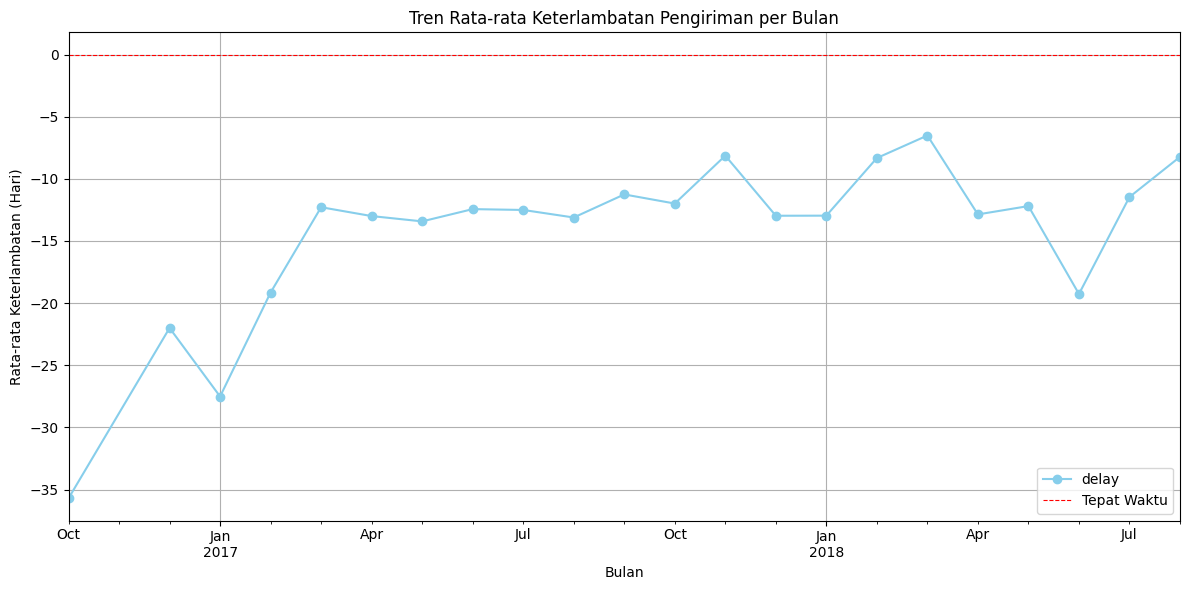

In [ ]:
# Visualize Delay Categories
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_dist.index, y=delay_dist.values, palette='coolwarm')
plt.title('Distribusi Kategori Keterlambatan Pengiriman')
plt.xlabel('Kategori Keterlambatan')
plt.ylabel('Persentase Pesanan (%)')
plt.tight_layout()
plt.show()

# Visualize Monthly Delay Trend
plt.figure(figsize=(12, 6))
monthly_delay.plot(kind='line', marker='o', color='skyblue')
plt.title('Tren Rata-rata Keterlambatan Pengiriman per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Keterlambatan (Hari)')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Tepat Waktu') # Add a line for 0 delay
plt.legend()
plt.tight_layout()
plt.show()

Dilakukan analisis performa pengiriman dengan:
- Menghitung waktu pengiriman dan keterlambatan (delay)
- Melakukan segmentasi (binning) menjadi 3 kategori:
  - On Time / Early
  - Slight Delay
  - Late
- Menganalisis distribusi kategori dan tren keterlambatan per bulan

**Insight:**
- Mayoritas pesanan (±93.26%) berada pada kategori tepat waktu atau lebih cepat → performa sangat baik.
- Keterlambatan hanya terjadi pada sebagian kecil pesanan:
  - Late: ±4.84%
  - Slight Delay: ±1.91%
- Rata-rata delay bernilai negatif di semua bulan → pengiriman konsisten lebih cepat dari estimasi.
- Terdapat variasi kecil antar bulan, tetapi tidak ada lonjakan keterlambatan yang signifikan.
- Kasus keterlambatan yang ada cenderung minor dan tidak dominan.

## Analisis Lanjutan: RFM Analysis

Proses analisis RFM dilakukan dengan mengelompokkan pelanggan berdasarkan tiga metrik utama, yaitu **Recency, Frequency, dan Monetary**. Pertama, data difilter hanya untuk pesanan yang telah selesai (delivered), kemudian dihitung **Recency** sebagai jumlah hari sejak transaksi terakhir pelanggan, **Frequency** sebagai jumlah total transaksi, dan **Monetary** sebagai total nilai pembelian. Setelah itu, setiap metrik diberikan skor menggunakan metode binning (qcut) untuk membagi pelanggan ke dalam beberapa kelompok. Skor tersebut kemudian dijumlahkan menjadi **RFM score** yang digunakan untuk melakukan segmentasi pelanggan ke dalam kategori seperti High Value, Medium Value, dan Low Value. Hasil segmentasi ini membantu memahami perilaku pelanggan dan memberikan dasar untuk strategi bisnis seperti retensi, promosi, dan peningkatan loyalitas pelanggan.

In [34]:
# Persiapan Data
# Pastikan hanya order yang selesai
df_rfm = df[df['order_status'] == 'delivered'].copy()

# Pastikan kolom datetime
df_rfm['order_purchase_timestamp'] = pd.to_datetime(df_rfm['order_purchase_timestamp'])

In [35]:
# Tentukan Reference Data
# tanggal terakhir dalam dataset
latest_date = df_rfm['order_purchase_timestamp'].max()

In [36]:
# Hitung RFM
rfm = df_rfm.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,  # Recency
    'order_id': 'count',                                                # Frequency
    'payment_value': 'sum'                                              # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,287,1,114.74
000161a058600d5901f007fab4c27140,409,1,67.41
0001fd6190edaaf884bcaf3d49edf079,547,1,195.42
0002414f95344307404f0ace7a26f1d5,378,1,179.35
000379cdec625522490c315e70c7a9fb,149,1,107.01


In [37]:
# Scoring RFM (Binning)
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])

In [38]:
# Hitung RFM Score Total
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,287,1,114.74,2,1,3,6
000161a058600d5901f007fab4c27140,409,1,67.41,1,1,2,4
0001fd6190edaaf884bcaf3d49edf079,547,1,195.42,1,1,4,6
0002414f95344307404f0ace7a26f1d5,378,1,179.35,1,1,4,6
000379cdec625522490c315e70c7a9fb,149,1,107.01,3,1,3,7


In [39]:
# Segmentasi Customer (Clustering Manual)
def segment_customer(score):
    if score >= 10:
        return 'High Value'
    elif score >= 6:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['segment'] = rfm['RFM_score'].apply(segment_customer)

In [40]:
# Distribusi Segment
rfm['segment'].value_counts()

,count
segment,
Medium Value,66187
High Value,15158
Low Value,15132


In [41]:
# Rata-rata per Segment
rfm.groupby('segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
segment,,,
High Value,113.251616,1.084180,277.373135
Low Value,371.474095,1.000000,63.233204
Medium Value,237.681478,1.045371,155.033389


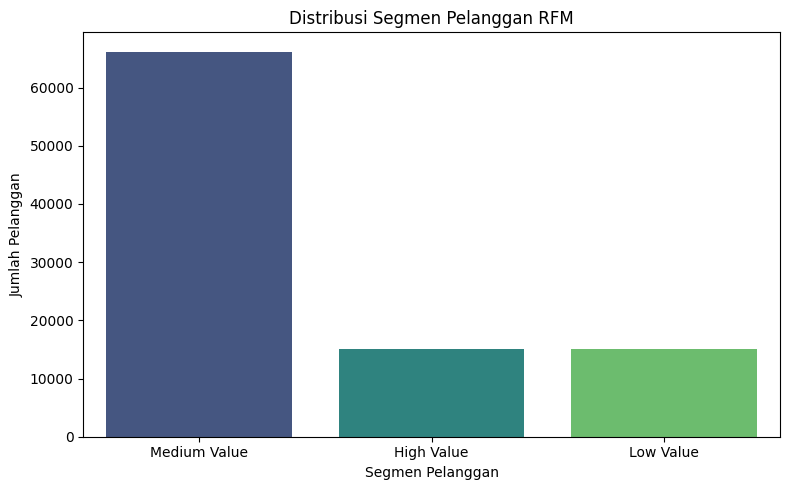

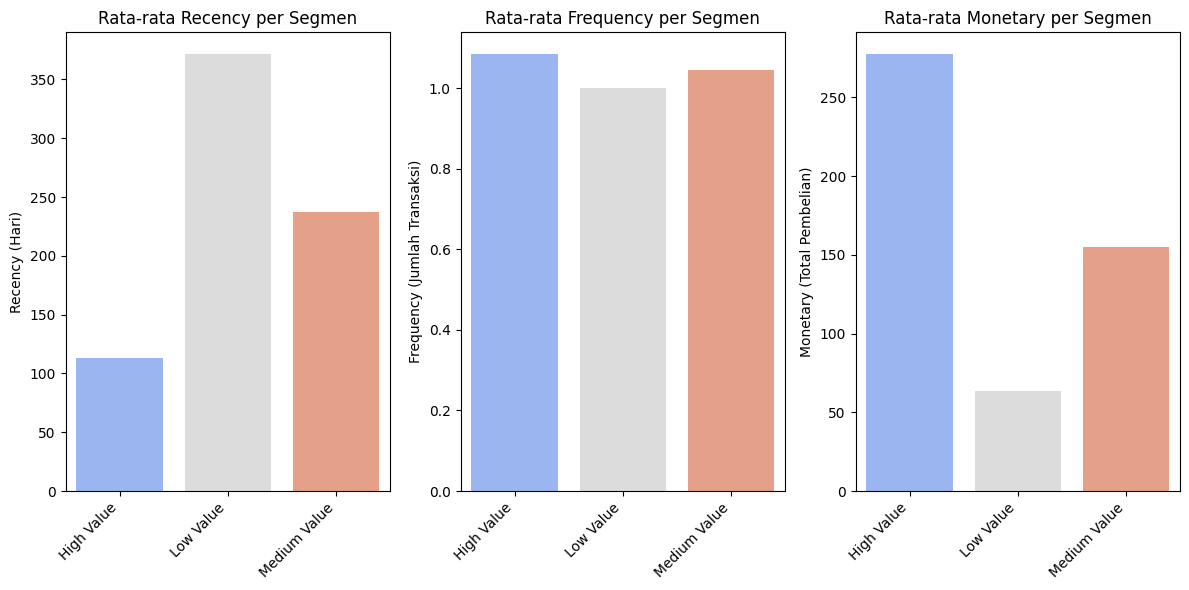

In [43]:
# Visualisasi Distribusi Segmentasi Pelanggan
plt.figure(figsize=(8, 5))
sns.barplot(x=rfm['segment'].value_counts().index, y=rfm['segment'].value_counts().values, palette='viridis')
plt.title('Distribusi Segmen Pelanggan RFM')
plt.xlabel('Segmen Pelanggan')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

# Visualisasi Rata-rata RFM per Segmen
rfm_mean_segment = rfm.groupby('segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='segment', y='Recency', data=rfm_mean_segment, palette='coolwarm')
plt.title('Rata-rata Recency per Segmen')
plt.ylabel('Recency (Hari)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.barplot(x='segment', y='Frequency', data=rfm_mean_segment, palette='coolwarm')
plt.title('Rata-rata Frequency per Segmen')
plt.ylabel('Frequency (Jumlah Transaksi)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x='segment', y='Monetary', data=rfm_mean_segment, palette='coolwarm')
plt.title('Rata-rata Monetary per Segmen')
plt.ylabel('Monetary (Total Pembelian)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Insight:**
- Mayoritas pelanggan berada pada segmen Medium Value (±66%) yang menunjukkan sebagian besar pelanggan memiliki kontribusi sedang terhadap bisnis.
- Segmen High Value (±15%) memiliki Monetary tertinggi (~277) dan Recency paling rendah → pelanggan aktif dan bernilai tinggi (loyal).
- Segmen Low Value (±15%) memiliki Recency tinggi (~371 hari) dan Monetary rendah → pelanggan sudah lama tidak bertransaksi (berisiko churn).
- Nilai Frequency rata-rata ~1 di semua segmen → sebagian besar pelanggan hanya melakukan 1 transaksi (one-time buyer).

## Conclusion

- **Conclusion Pertanyaan 1 (Tren Jumlah Pesanan Jan 2017 – Des 2018)**:
Secara keseluruhan, jumlah pesanan menunjukkan tren pertumbuhan yang signifikan sepanjang tahun 2017 hingga mencapai puncaknya pada akhir tahun. Memasuki tahun 2018, jumlah pesanan cenderung stabil dengan fluktuasi ringan di beberapa bulan. Hal ini menunjukkan bahwa bisnis telah memasuki fase yang lebih matang dengan volume transaksi yang relatif konsisten. Penurunan tajam yang terlihat pada akhir 2018 kemungkinan besar disebabkan oleh data yang belum lengkap sehingga tidak mencerminkan kondisi performa bisnis yang sebenarnya. Pola lonjakan pada akhir tahun juga mengindikasikan adanya efek musiman yang dapat dimanfaatkan untuk strategi promosi.
- **Conclusion Pertanyaan 2 (Metode Pembayaran & Revenue 2017 vs 2018)**:
Analisis menunjukkan bahwa metode pembayaran credit card merupakan metode yang paling dominan baik dari sisi frekuensi penggunaan maupun kontribusi terhadap total revenue pada tahun 2017 dan 2018. Selain itu, terjadi peningkatan revenue pada hampir seluruh metode pembayaran di tahun 2018 dibandingkan tahun sebelumnya yang mencerminkan pertumbuhan aktivitas transaksi. Metode seperti boleto masih memiliki kontribusi yang cukup signifikan, sementara metode lainnya seperti debit card dan voucher memberikan kontribusi yang relatif kecil. Temuan ini menunjukkan bahwa preferensi pelanggan cenderung mengarah pada metode pembayaran yang lebih praktis dan fleksibel sehingga optimalisasi pada metode tersebut dapat menjadi strategi yang efektif untuk meningkatkan revenue.
- **Conclusion Pertanyaan 3 (Kinerja Pengiriman Jan – Jun 2018)**:
Kinerja pengiriman pada periode Januari hingga Juni 2018 secara umum menunjukkan performa yang baik dengan sebagian besar pesanan dikirim dalam waktu sekitar 10 hari. Distribusi waktu pengiriman yang berada pada kisaran 0 hingga 50 hari menunjukkan adanya variasi durasi, tetapi mayoritas pesanan terkonsentrasi pada waktu pengiriman yang relatif cepat. Meskipun terdapat beberapa kasus pengiriman dengan durasi yang cukup lama (outlier), secara keseluruhan sistem logistik telah berjalan dengan cukup efisien. Hal ini mengindikasikan bahwa perusahaan mampu memenuhi ekspektasi pelanggan dalam hal kecepatan pengiriman, meskipun tetap diperlukan evaluasi untuk meminimalkan keterlambatan ekstrem.